## Задание Pro



1. Выберите 10 самых красивых по вашем мнению пятерок в тренировочной выборке mnist.
2. Создайте датасет, где объекты – это все пятерки из тренировочной части mnist, а метки – это случайные пятерки из "красивого" набора.
3. Создайте автокодировщик и проверьте, совпадают ли у него размеры выхода и входа.
4. Обучите автокодировщик.
5. Добейтесь ошибки MSE на тренировочной выборке **<0.05**.
6. Посмотрите, как выглядят пятерки из тестовой выборки после обученного автокодировщика.

## Импорт библиотек

In [1]:
# Для операций с тензорами
import numpy as np

# Для отрисвоки
import matplotlib.pyplot as plt

# Для создания модели
from tensorflow.keras.models import Model

# Необходимые слои
from tensorflow.keras.layers import Input, Conv2DTranspose, MaxPooling2D, Conv2D, BatchNormalization

# Слои для латентного пространства модели
from tensorflow.keras.layers import Flatten, Reshape, Dense

# Оптимизатор
from tensorflow.keras.optimizers import Adam

# Для загрузки базы
from tensorflow.keras.datasets import mnist

## Загрузка данных

In [2]:
# Загрузка датасета
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# Нормализация данных
X_train = X_train.astype('float32')/255.
X_test = X_test.astype('float32')/255.

In [4]:
# Приведение формы к удобной для Keras
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [5]:
# Отбор пятерок
mask = y_train == 5
X_train = X_train[mask]
y_train = y_train[mask]

In [6]:
# Аналогично для тестирования
mask = y_test == 5
X_test = X_test[mask]
y_test = y_test[mask]

## Отбор красивых пятерок

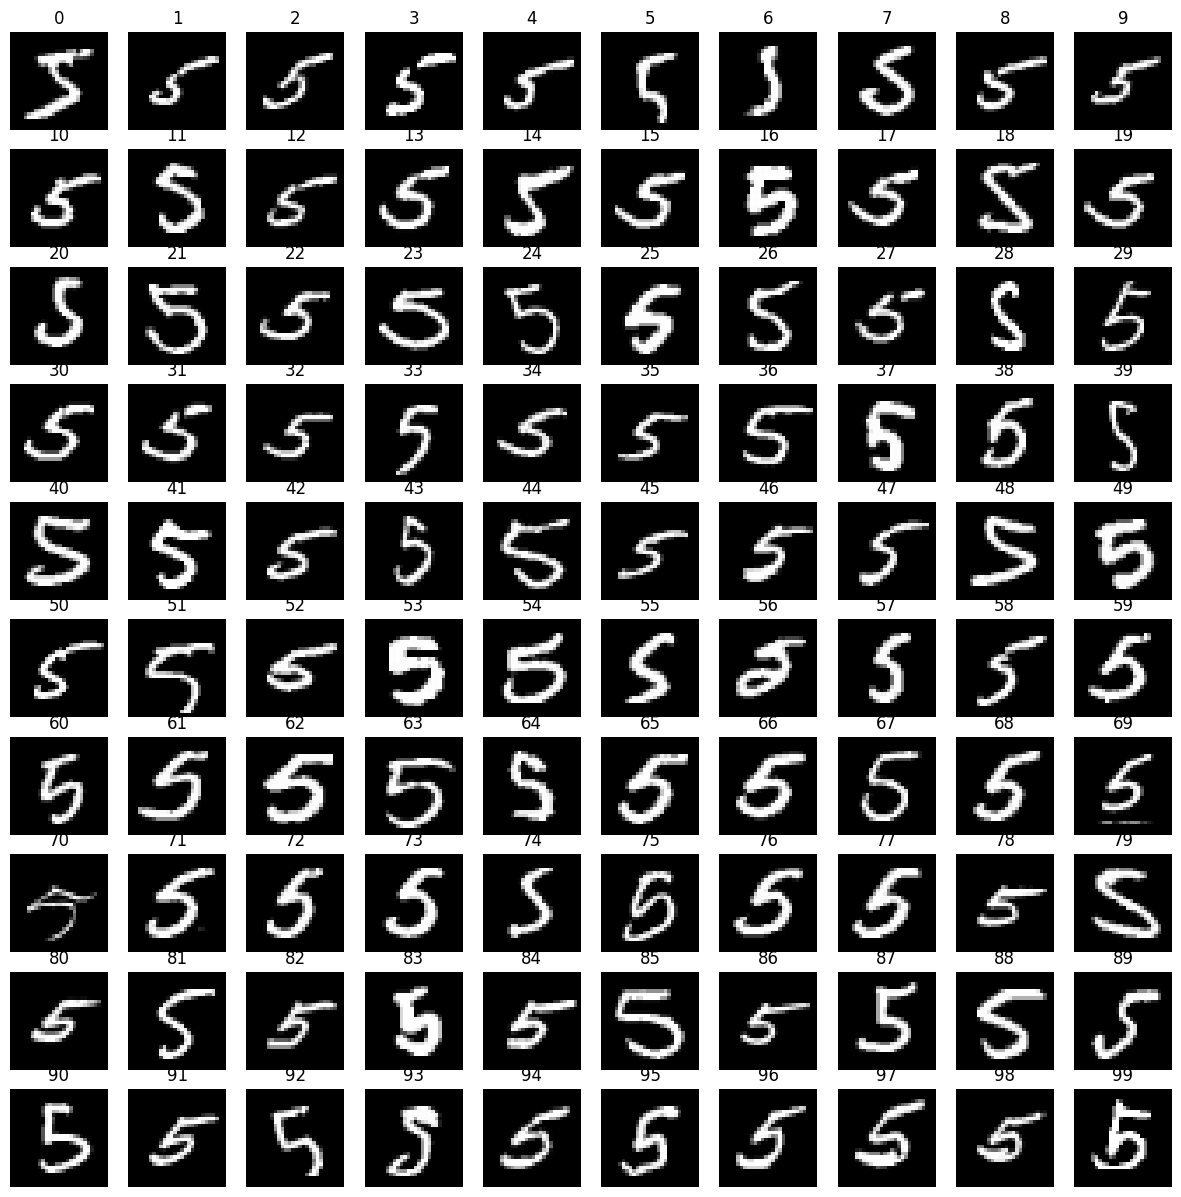

In [7]:
# Ваше решение
# Посмотрим первые 100 пятерок и выберем красивые вручную
plt.figure(figsize=(15, 15))

for i in range(100):
    plt.subplot(10, 10, i + 1)
    plt.imshow(X_train[i].reshape(28, 28), cmap='gray')
    plt.title(str(i))
    plt.axis('off')

plt.show()

Выведем 10 пятерок

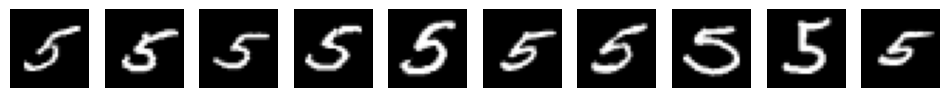

In [8]:
beautiful_idx = [2, 10, 32, 30, 76, 91, 94, 23, 87, 80]

best_fives = X_train[beautiful_idx]

plt.figure(figsize=(12, 3))

for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(best_fives[i].reshape(28, 28), cmap='gray')
    plt.axis('off')

plt.show()

In [9]:
# Индексы выбираются из набора "красивых пятерок"
random_idx = np.random.randint(0, len(best_fives), size=len(X_train))

X = X_train
Y = best_fives[random_idx]

print(X.shape)
print(Y.shape)

(5421, 28, 28, 1)
(5421, 28, 28, 1)


In [10]:
# Входное изображение
input_img = Input(shape=(28, 28, 1))

# Encoder
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = BatchNormalization()(x)

# Уменьшение размера изображения:
# 28x28 -> 14x14
x = MaxPooling2D((2, 2), padding='same')(x)

x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
# Второе уменьшение размера:
# 14x14 -> 7x7
x = MaxPooling2D((2, 2), padding='same')(x)

x = Flatten()(x)
latent = Dense(64, activation='relu')(x)

# Decoder

# Восстановление размерности:
# из latent vector обратно в 7x7x64
x = Dense(7 * 7 * 64, activation='relu')(latent)
x = Reshape((7, 7, 64))(x)

# Первый слой восстановления изображения:
# 7x7 -> 14x14
x = Conv2DTranspose(64, (3, 3), strides=2, activation='relu', padding='same')(x)
x = BatchNormalization()(x)

# Второй слой восстановления:
# 14x14 -> 28x28
x = Conv2DTranspose(32, (3, 3), strides=2, activation='relu', padding='same')(x)
x = BatchNormalization()(x)

output_img = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# Создание полной модели автокодировщика
autoencoder = Model(input_img, output_img)

autoencoder.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3136)           │       203,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 479,873 (1.83 MB)

 Trainable params: 479,489 (1.83 MB)

 Non-trainable params: 384 (1.50 KB)

In [11]:
print("Input shape:", autoencoder.input_shape)
print("Output shape:", autoencoder.output_shape)

Input shape: (None, 28, 28, 1)
Output shape: (None, 28, 28, 1)


In [12]:
history = autoencoder.fit(
    X,
    Y,
    epochs=30,
    batch_size=128,
    shuffle=True
)

Epoch 1/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 13s 92ms/step - loss: 0.1108
Epoch 2/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0625
Epoch 3/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0617
Epoch 4/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0615
Epoch 5/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0614
Epoch 6/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0613
Epoch 7/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0611
Epoch 8/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0608
Epoch 9/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0595
Epoch 10/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0589
Epoch 11/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0582
Epoch 12/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0548
Epoch 13/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0513
Epoch 14/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0456
Epoch 15/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0428
Epoch 

In [13]:
final_mse = history.history['loss'][-1]
print("Final MSE:", final_mse)

Final MSE: 0.007009110879153013


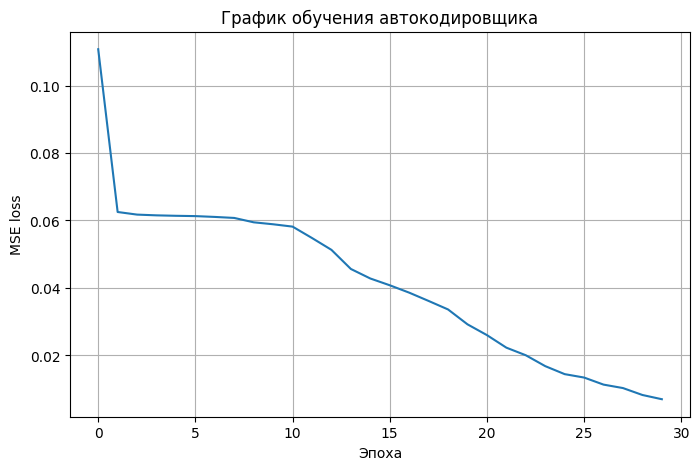

In [14]:
# График обучения
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'])
plt.title('График обучения автокодировщика')
plt.xlabel('Эпоха')
plt.ylabel('MSE loss')
plt.grid(True)
plt.show()

28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step


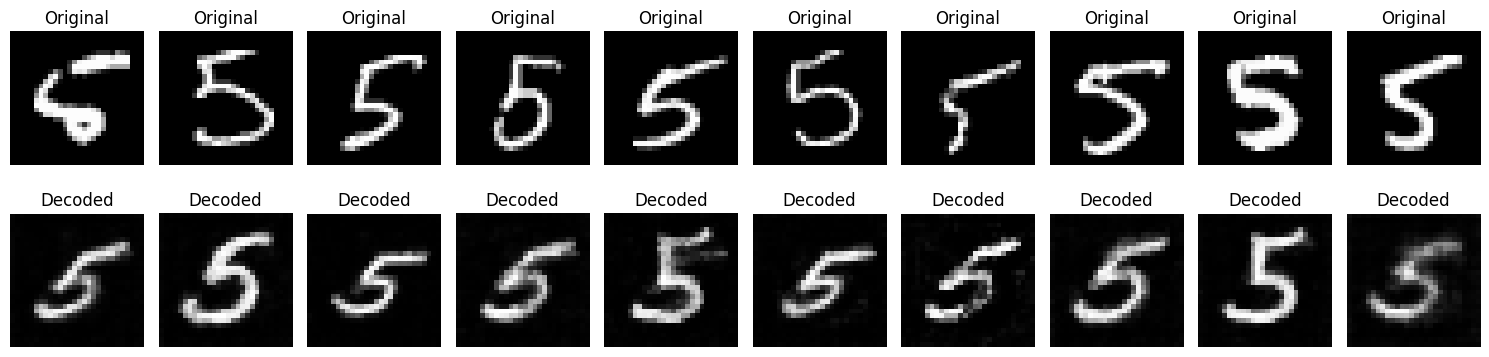

In [15]:
# Проверка автокодировщика на тестовых пятерках
pred_test = autoencoder.predict(X_test)

# Количество изображений для отображения
n = 10

plt.figure(figsize=(15, 4))

for i in range(n):

    # Оригинальные изображения
    plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title('Original')
    plt.axis('off')

    # Результат после автокодировщика
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(pred_test[i].reshape(28, 28), cmap='gray')
    plt.title('Decoded')
    plt.axis('off')

plt.tight_layout()
plt.show()